# 01 Signals, Systems, and Sampling

## Purpose

This notebook establishes the basic language of signal processing: what a signal is, what it means to sample one, why aliasing happens, and how finite quantization changes what we can represent numerically.

## Prerequisites

- Basic algebra and trigonometry
- Familiarity with sine waves is helpful but not required

## Learning Objectives

By the end of this notebook, you should be able to:

- explain the difference between a continuous-time description and a sampled signal,
- describe what the sampling rate controls,
- explain aliasing in plain language,
- describe how quantization introduces error,
- and reason about the tradeoff between fidelity, storage, and hardware burden.


## New Terms In This Notebook

- **Continuous-time signal**: an ideal signal described as if it exists at every instant of time.
- **Sampled signal**: the sequence of discrete measurements kept by the processor after sampling.
- **Sampling rate**: how many samples are taken each second, usually measured in hertz.
- **Nyquist rate**: twice the highest frequency present in the signal. Sampling above this rate avoids frequency overlap in the ideal case.
- **Aliasing**: the ambiguity created when different underlying waveforms produce the same sampled data because the sampling rate is too low.
- **Quantization**: mapping each sample onto a finite set of allowed amplitude values.
- **Bit depth**: the number of bits used to store each sample, which controls how many quantization levels are available.

## Big Picture

Most sensing systems do not work directly with an ideal continuous waveform. They measure values at discrete times, store them with finite numerical precision, and then process those samples. That means two early design choices matter immediately:

1. How often do we sample?
2. How finely do we represent each sample?

Those two choices drive whether we preserve the information we care about or accidentally destroy it before any advanced processing begins.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import quantize_signal, sine_wave, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal, plot_signals, plot_stem

set_plot_style()

## Assumptions

- We start with idealized sinusoids because they make sampling effects easy to see.
- We treat a sampled signal as the values available to the processor.
- We ignore hardware details like jitter, anti-alias filters, and nonuniform sampling for now.
- We use simple uniform quantization as a first model of finite precision.


## Signals and Systems in Plain Language

A **signal** is a quantity that changes in time or space. Examples include voltage, pressure, acoustic intensity, or reflected sonar amplitude.

A **system** is something that takes an input signal and produces an output signal. A sensor, amplifier, filter, sampler, and image former are all systems.

In this notebook we focus on the first key system in the chain: the sampler. It converts a continuously varying signal into a sequence of samples.


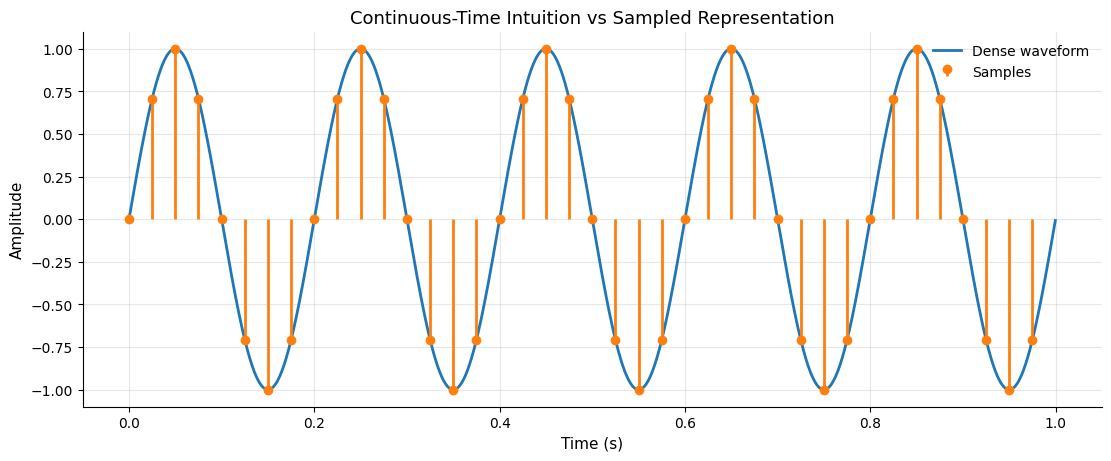

In [2]:
# A dense waveform stands in for an ideal continuous-time signal.
f_signal = 5.0
duration_s = 1.0

t_dense = np.linspace(0.0, duration_s, 4000, endpoint=False)
x_dense = np.sin(2.0 * np.pi * f_signal * t_dense)

# A sampled representation keeps only specific points from the waveform.
fs_sampled = 40.0
t_sampled, x_sampled = sine_wave(f_signal, fs_sampled, duration_s)

fig, ax = make_figure(figsize=(11, 4.5))
plot_signal(t_dense, x_dense, ax=ax, title="Continuous-Time Intuition vs Sampled Representation", xlabel="Time (s)", ylabel="Amplitude", label="Dense waveform")
ax.stem(t_sampled, x_sampled, linefmt="C1-", markerfmt="C1o", basefmt=" ", label="Samples")
ax.legend(loc="upper right")
plt.show()

The dense curve is not truly continuous either. It is just sampled so finely that it behaves like a stand-in for the ideal waveform. The important point is conceptual: the processor never gets the full curve. It gets the orange sample values.


## Sampling Rate Controls Time Detail

The sampling rate tells us how many measurements we take each second. A higher rate preserves more temporal detail, but it costs more in storage, bandwidth, and computation.

Below we sample the same signal at three different rates.


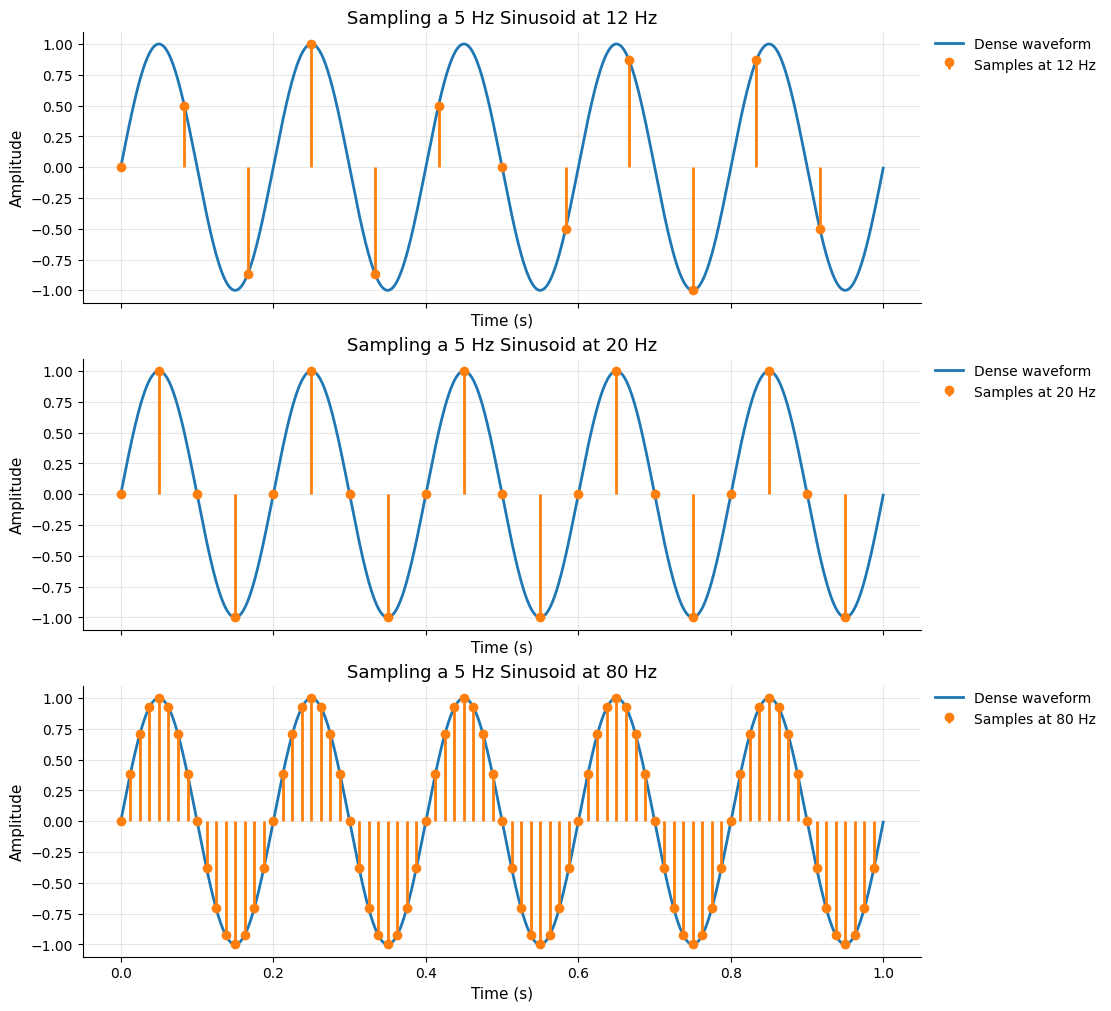

In [3]:
sample_rates = [12.0, 20.0, 80.0]
fig, axes = make_figure(nrows=3, ncols=1, figsize=(11, 10), sharex=True)

for ax, fs in zip(np.atleast_1d(axes), sample_rates):
    t_disc, x_disc = sine_wave(f_signal, fs, duration_s)
    plot_signal(t_dense, x_dense, ax=ax, xlabel="Time (s)", ylabel="Amplitude", label="Dense waveform")
    ax.stem(t_disc, x_disc, linefmt="C1-", markerfmt="C1o", basefmt=" ", label=f"Samples at {fs:.0f} Hz")
    ax.set_title(f"Sampling a 5 Hz Sinusoid at {fs:.0f} Hz")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

plt.show()

At 80 Hz, the samples trace the waveform clearly. At 20 Hz, they are still informative. At 12 Hz, we are much closer to the minimum acceptable rate, so the waveform shape is far less obvious from the samples alone.

This motivates the Nyquist idea: if a signal contains frequency content up to $f_{max}$, then we need a sampling rate above $2 f_{max}$ to avoid frequency overlap in the sampled representation.


## Aliasing

Aliasing occurs when we sample too slowly for the signal we are trying to represent. A higher-frequency waveform can produce the exact same samples as a lower-frequency waveform, so the processor cannot tell which one was present.

That is not a small estimation error. It is a loss of information caused by the sampling decision itself.


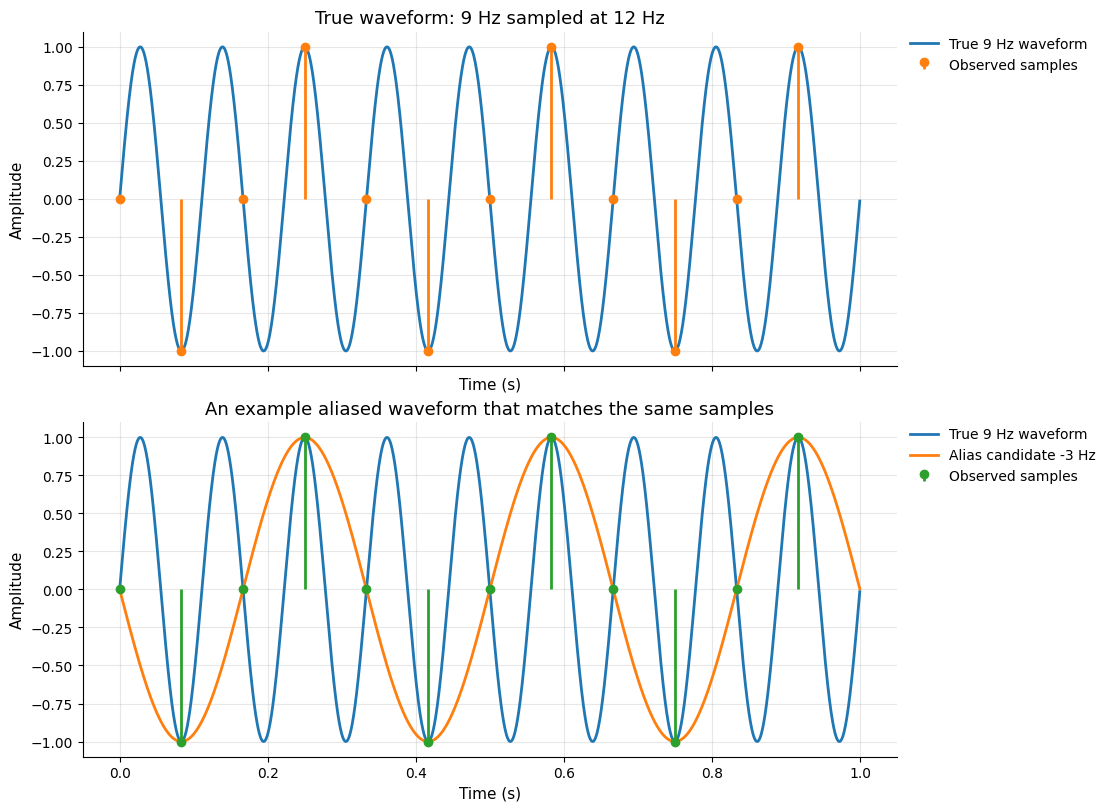

A 9.0 Hz sinusoid sampled at 12.0 Hz aliases to -3.0 Hz.


In [4]:
fs_alias = 12.0
f_true = 9.0
f_alias = f_true - round(f_true / fs_alias) * fs_alias

t_dense_alias = np.linspace(0.0, duration_s, 4000, endpoint=False)
x_true_dense = np.sin(2.0 * np.pi * f_true * t_dense_alias)
x_alias_dense = np.sin(2.0 * np.pi * f_alias * t_dense_alias)
t_alias, x_alias_samples = sine_wave(f_true, fs_alias, duration_s)

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11, 8), sharex=True)

plot_signal(t_dense_alias, x_true_dense, ax=axes[0], title=f"True waveform: {f_true:.0f} Hz sampled at {fs_alias:.0f} Hz", xlabel="Time (s)", ylabel="Amplitude", label="True 9 Hz waveform")
axes[0].stem(t_alias, x_alias_samples, linefmt="C1-", markerfmt="C1o", basefmt=" ", label="Observed samples")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

plot_signals(t_dense_alias, [x_true_dense, x_alias_dense], ax=axes[1], labels=["True 9 Hz waveform", f"Alias candidate {f_alias:.0f} Hz"], title="An example aliased waveform that matches the same samples", xlabel="Time (s)", ylabel="Amplitude")
axes[1].stem(t_alias, x_alias_samples, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="Observed samples")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

plt.show()
print(f"A {f_true:.1f} Hz sinusoid sampled at {fs_alias:.1f} Hz aliases to {f_alias:.1f} Hz.")

This is the key intuition: after sampling, the 9 Hz and 3 Hz interpretations are indistinguishable from the samples alone. Once that happens, no later algorithm can recover the truth without additional prior information.


## Quantization

Sampling chooses **when** we measure. Quantization chooses **how precisely** we store each sample.

If the bit depth is low, the signal is forced onto coarse amplitude levels. That introduces quantization error, which can behave like a form of noise or distortion.


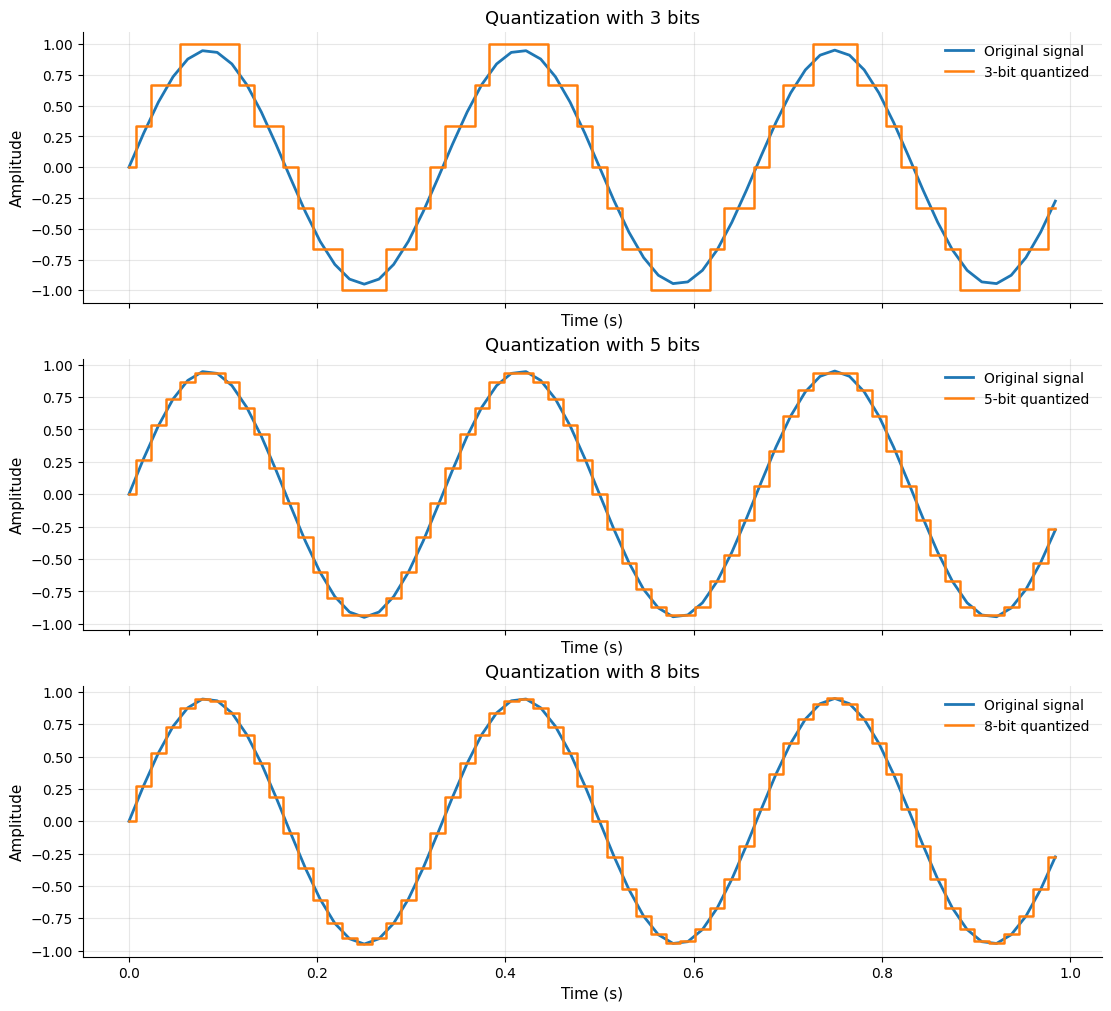

In [5]:
t_quant, x_quant_source = sine_wave(3.0, 64.0, 1.0, amplitude=0.95)
bit_depths = [3, 5, 8]

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11, 10), sharex=True)

for ax, bits in zip(np.atleast_1d(axes), bit_depths):
    x_quantized = quantize_signal(x_quant_source, bits, full_scale=1.0)
    plot_signal(t_quant, x_quant_source, ax=ax, xlabel="Time (s)", ylabel="Amplitude", label="Original signal")
    ax.step(t_quant, x_quantized, where="mid", label=f"{bits}-bit quantized", linewidth=1.8)
    ax.set_title(f"Quantization with {bits} bits")
    ax.legend()

plt.show()

In [6]:
print("Mean absolute quantization error by bit depth:")
for bits in bit_depths:
    x_quantized = quantize_signal(x_quant_source, bits, full_scale=1.0)
    error = np.mean(np.abs(x_quant_source - x_quantized))
    print(f"  {bits} bits: {error:.5f}")

Mean absolute quantization error by bit depth:
  3 bits: 0.08534
  5 bits: 0.01311
  8 bits: 0.00209


The quantized curves become better approximations as bit depth increases. More bits reduce quantization error, but they increase storage, memory traffic, and interface requirements.


## A Minimal System Example

A system maps one signal to another. Here is a deliberately simple example: a gain block that doubles the input amplitude.

$$
y[n] = 2 x[n]
$$

This is not a realistic signal-processing chain yet, but it makes the point: once we have samples, systems operate on those samples to produce new sequences. Later notebooks will study richer systems such as filters, correlators, and matched filters.


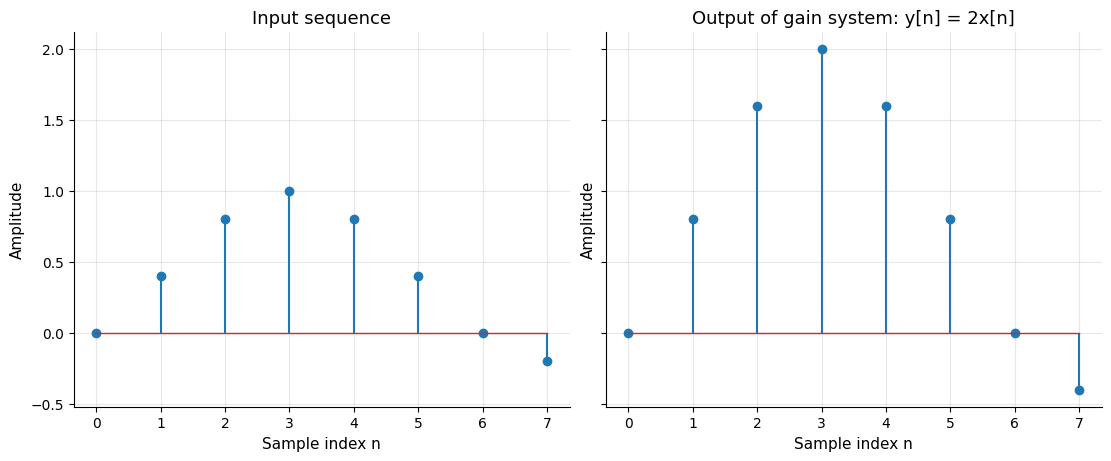

In [7]:
n = np.arange(8)
x_n = np.array([0.0, 0.4, 0.8, 1.0, 0.8, 0.4, 0.0, -0.2])
y_n = 2.0 * x_n

fig, axes = make_figure(nrows=1, ncols=2, figsize=(11, 4.5), sharey=True)
plot_stem(n, x_n, ax=axes[0], title="Input sequence", xlabel="Sample index n", ylabel="Amplitude")
plot_stem(n, y_n, ax=axes[1], title="Output of gain system: y[n] = 2x[n]", xlabel="Sample index n", ylabel="Amplitude")
plt.show()

## Tradeoffs and Limitations

### Sampling rate tradeoffs

- Higher sampling rates preserve more time detail and reduce aliasing risk.
- Higher sampling rates increase storage, data movement, and computational cost.
- A rate that is only barely acceptable can still make interpretation fragile.

### Quantization tradeoffs

- Higher bit depth reduces quantization error.
- Higher bit depth increases memory and interface cost.
- Low-bit systems can still be useful if the rest of the chain is designed around that constraint.

### What this notebook leaves out

- anti-alias filtering before sampling,
- sample clock jitter,
- nonuniform sampling,
- and realistic analog front-end behavior.

Those effects matter in practice, but the core ideas here need to be solid first.


## Recap

- A sampled signal is a sequence of measurements taken from an underlying waveform.
- The sampling rate determines how much time detail can be represented without ambiguity.
- Aliasing is a structural loss of information caused by sampling too slowly.
- Quantization limits amplitude precision and introduces representation error.
- These choices shape every later processing stage.


## Suggested Next Questions

- Why are sinusoids such a natural language for signals?
- How does phase appear in sampled data?
- Why do complex exponentials make later signal-processing math easier?

The next notebook answers those questions by focusing on sinusoids, complex exponentials, and phase.
